# Databricks EDA — logistics_operations.default

Profiles the 9 live tables (`customers`, `drivers`, `facilities`, `fuel_purchases`, `loads`, `routes`, `trailers`, `trips`, `trucks`): row counts, nulls, key uniqueness, dates, sums, FK orphans. Fills `docs/FINDINGS.md` rows 4–12.

In [1]:
# setup: paths, plotting theme, output folders
import json
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid")
cwd = Path.cwd()
ROOT = cwd if (cwd / "notebooks").is_dir() else cwd.parent
PLOTS = ROOT / "notebooks" / "plots"
PLOTS.mkdir(exist_ok=True)
import sys

sys.path.insert(0, str(ROOT))

In [2]:
# load all 9 tables from the warehouse
from src.utils import read_databricks

TABLES = [
    "customers",
    "drivers",
    "facilities",
    "fuel_purchases",
    "loads",
    "routes",
    "trailers",
    "trips",
    "trucks",
]
frames = {}
for table in TABLES:
    frames[table] = read_databricks(
        f"SELECT * FROM logistics_operations.default.{table}"
    )
    print(table, frames[table].shape)

2026-10-05 14:23:55,833 INFO databricks.sql.auth.retry: Received status code 200 for POST request


2026-10-05 14:23:55,837 INFO databricks.sql.auth.thrift_http_client: HTTP Response with status code 200, message: OK


2026-10-05 14:23:55,839 INFO databricks.sql.session: Successfully opened session 01f1c09a-4e36-1df6-839a-d5591c699df1


2026-10-05 14:23:57,053 INFO databricks.sql.auth.retry: Received status code 200 for GET request


2026-10-05 14:23:57,074 INFO src.utils.connection: databricks connected host=dbc-f19f322c-4167.cloud.databricks.com


...

2026-10-05 14:25:21,649 INFO src.utils.engine: databricks read rows=120


2026-10-05 14:25:21,650 INFO databricks.sql.session: Closing session 01f1c09a-810c-1ec0-b30b-e840e5400680


2026-10-05 14:25:21,953 INFO databricks.sql.auth.retry: Received status code 200 for POST request


2026-10-05 14:25:21,954 INFO databricks.sql.auth.thrift_http_client: HTTP Response with status code 200, message: OK


trucks (120, 12)


In [3]:
# per-table profile: nulls, uniques, numeric and date summaries
def profile(frame):
    cols = {}
    for c in frame.columns:
        s = frame[c]
        info = {
            "null_pct": round(float(s.isna().mean()) * 100, 2),
            "uniques": int(s.nunique(dropna=True)),
        }
        num = pd.to_numeric(s, errors="coerce")
        if num.notna().mean() >= 0.95 and info["uniques"] > 2:
            info["sum"] = round(float(num.sum()), 2)
            info["mean"] = round(float(num.mean()), 2)
            info["min"], info["max"] = (
                round(float(num.min()), 2),
                round(float(num.max()), 2),
            )
        if s.dtype == object:
            d = pd.to_datetime(s, errors="coerce", format="mixed")
            if d.notna().mean() >= 0.90:
                info["dmin"], info["dmax"] = str(d.min()), str(d.max())
        cols[str(c)] = info
    return {
        "rows": len(frame),
        "dupe_rows": int(frame.duplicated().sum()),
        "columns": cols,
    }


stats = {name: profile(frame) for name, frame in frames.items()}
for name, st in stats.items():
    bad = {c: v["null_pct"] for c, v in st["columns"].items() if v["null_pct"] > 0}
    print(name, "rows=", st["rows"], "dupes=", st["dupe_rows"], "nulls>", bad)

2026-10-05 14:25:23,302 INFO databricks.sql.auth.retry: Received status code 200 for POST request


customers rows= 200 dupes= 0 nulls> {}
drivers rows= 150 dupes= 0 nulls> {'termination_date': 82.67}
facilities rows= 50 dupes= 0 nulls> {}
fuel_purchases rows= 196442 dupes= 0 nulls> {'truck_id': 1.98, 'driver_id': 2.03}
loads rows= 85410 dupes= 0 nulls> {}
routes rows= 58 dupes= 0 nulls> {}
trailers rows= 180 dupes= 0 nulls> {}
trips rows= 85410 dupes= 0 nulls> {'driver_id': 2.01, 'truck_id': 1.96, 'trailer_id': 1.97}
trucks rows= 120 dupes= 0 nulls> {}


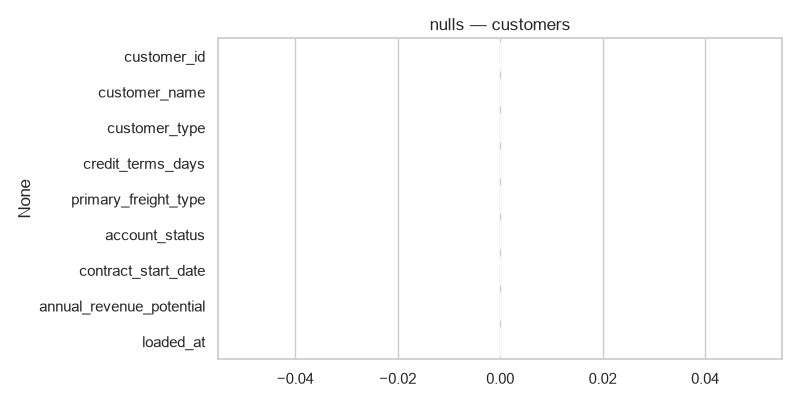

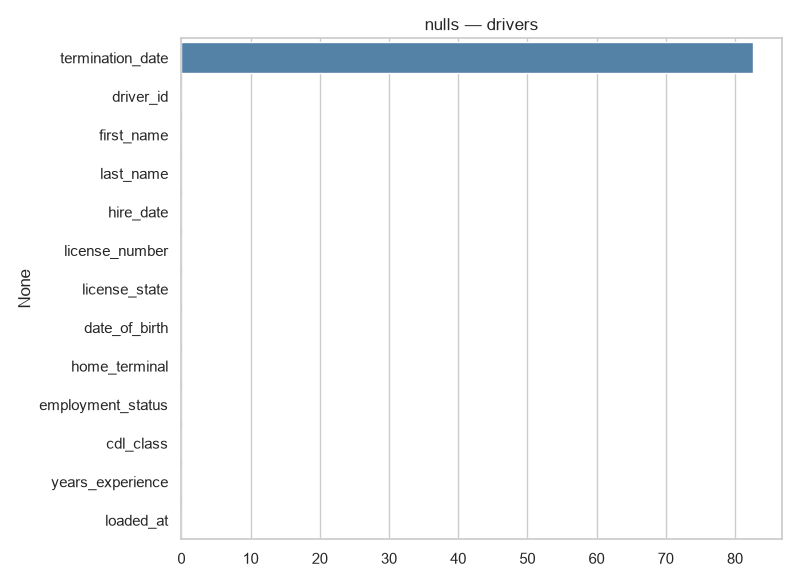

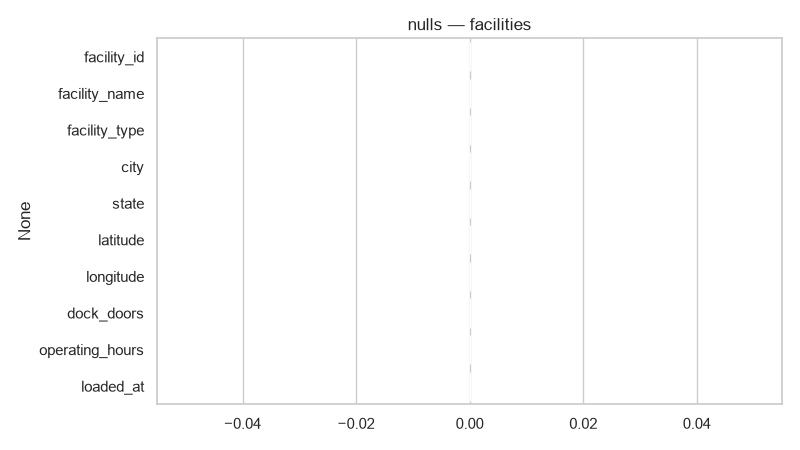

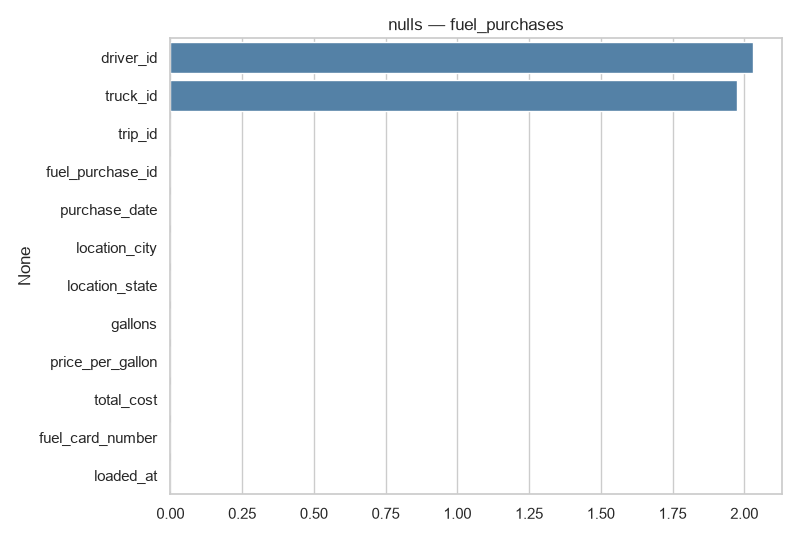

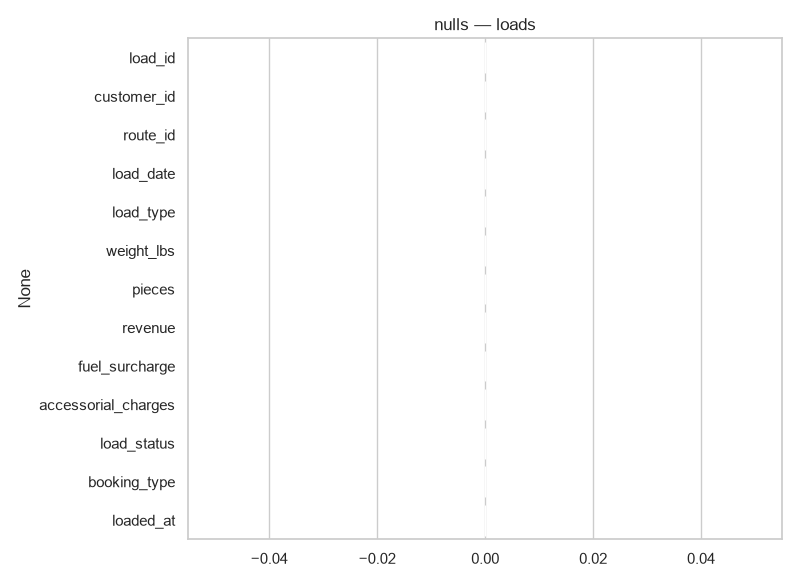

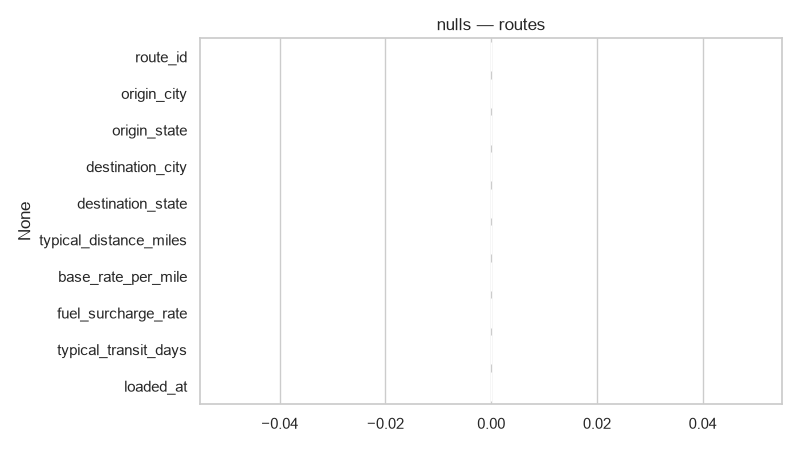

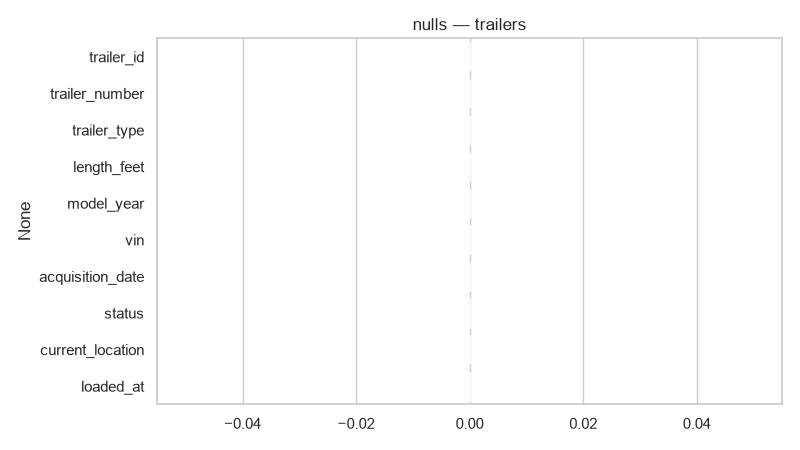

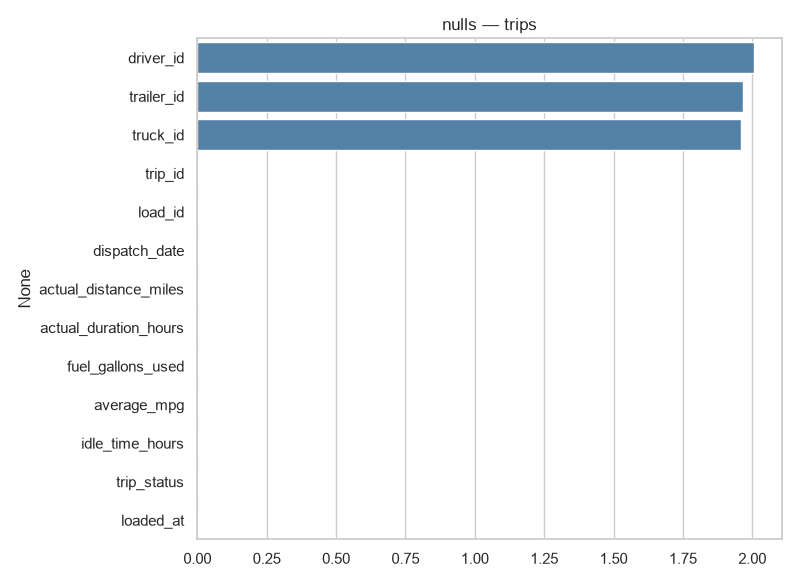

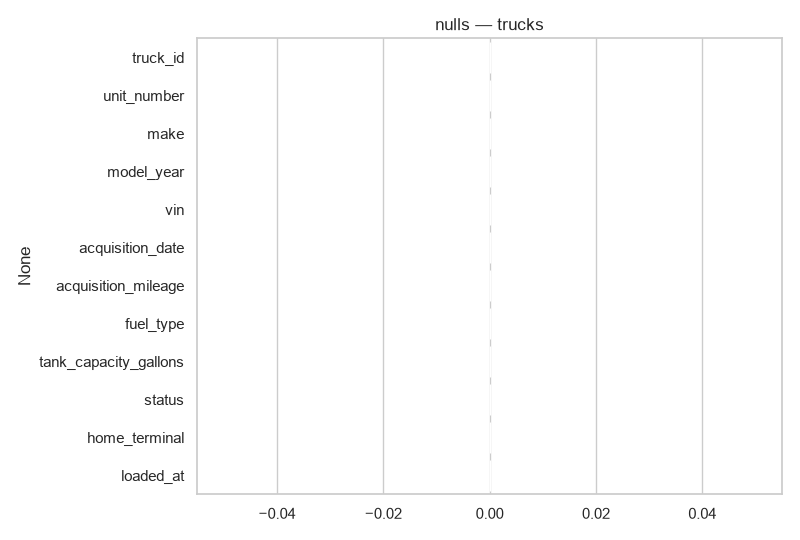

In [4]:
# null-share bar per table
for name, frame in frames.items():
    vals = frame.isna().mean().mul(100).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, max(3, len(vals) * 0.45)))
    sns.barplot(x=vals.values, y=vals.index, ax=ax, color="steelblue")
    ax.set_title(f"nulls — {name}")
    fig.tight_layout()
    path = PLOTS / f"nulls_{name}.png"
    fig.savefig(path, dpi=100)
    plt.close(fig)
    display(Image(str(path)))

In [5]:
# key uniqueness on the candidate primary keys
KEYS = {
    "customers": "customer_id",
    "drivers": "driver_id",
    "facilities": "facility_id",
    "fuel_purchases": "fuel_purchase_id",
    "loads": "load_id",
    "routes": "route_id",
    "trailers": "trailer_id",
    "trips": "trip_id",
    "trucks": "truck_id",
}
for name, key in KEYS.items():
    dupes = int(frames[name].duplicated(subset=[key]).sum())
    stats[name]["key_dupes"] = dupes
    print(name, key, "dupe_rows=", dupes)

customers customer_id dupe_rows= 0
drivers driver_id dupe_rows= 0
facilities facility_id dupe_rows= 0
fuel_purchases fuel_purchase_id dupe_rows= 0
loads load_id dupe_rows= 0
routes route_id dupe_rows= 0
trailers trailer_id dupe_rows= 0
trips trip_id dupe_rows= 0
trucks truck_id dupe_rows= 0


loads revenue sum= 262525800.29
loads fuel_surcharge sum= 29976528.65
loads accessorial_charges sum= 6119100
loads weight_lbs sum= 2346852874
loads pieces sum= 1235928
fuel gallons sum= 24519037.8
fuel total_cost sum= 95592992.04
fuel price_per_gallon sum= 765813.056
trips actual_distance_miles sum= 122159201
trips fuel_gallons_used sum= 18946280.1
trips idle_time_hours sum= 598791.0
routes base_rate sum= 127.41


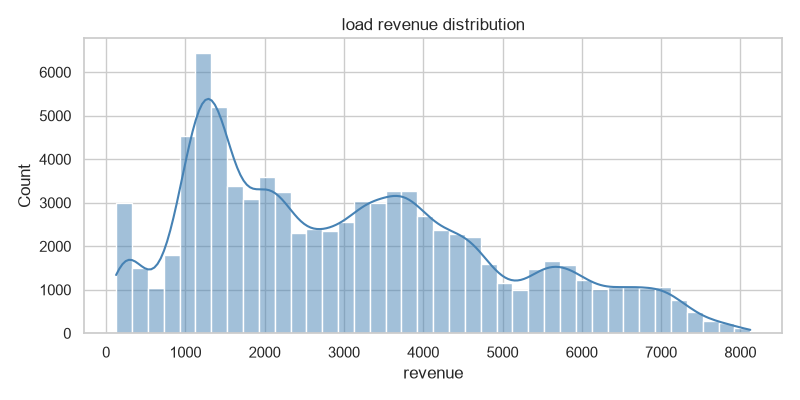

In [6]:
# money and volume sums across the fact tables
loads = frames["loads"]
fuel = frames["fuel_purchases"]
trips = frames["trips"]
for col in ["revenue", "fuel_surcharge", "accessorial_charges", "weight_lbs", "pieces"]:
    print("loads", col, "sum=", pd.to_numeric(loads[col], errors="coerce").sum())
for col in ["gallons", "total_cost", "price_per_gallon"]:
    print("fuel", col, "sum=", pd.to_numeric(fuel[col], errors="coerce").sum())
for col in ["actual_distance_miles", "fuel_gallons_used", "idle_time_hours"]:
    print("trips", col, "sum=", pd.to_numeric(trips[col], errors="coerce").sum())
print(
    "routes base_rate sum=",
    pd.to_numeric(frames["routes"]["base_rate_per_mile"], errors="coerce").sum(),
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    pd.to_numeric(loads["revenue"], errors="coerce").dropna(),
    bins=40,
    kde=True,
    ax=ax,
    color="steelblue",
)
ax.set_title("load revenue distribution")
fig.tight_layout()
fig.savefig(PLOTS / "hist_load_revenue.png", dpi=100)
plt.close(fig)
display(Image(str(PLOTS / "hist_load_revenue.png")))

2026-10-05 14:25:27,132 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-10-05 14:25:27,138 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


loads load_date 2022-01-01 -> 2024-12-31 null_pct= 0.0
trips dispatch_date 2022-01-01 -> 2024-12-31 null_pct= 0.0
fuel_purchases purchase_date 2022-01-01 00:00:00+00:00 -> 2025-01-02 23:00:00+00:00 null_pct= 0.0
drivers hire_date 2012-01-28 -> 2021-12-06 null_pct= 0.0
customers contract_start_date 2020-01-07 -> 2022-01-01 null_pct= 0.0


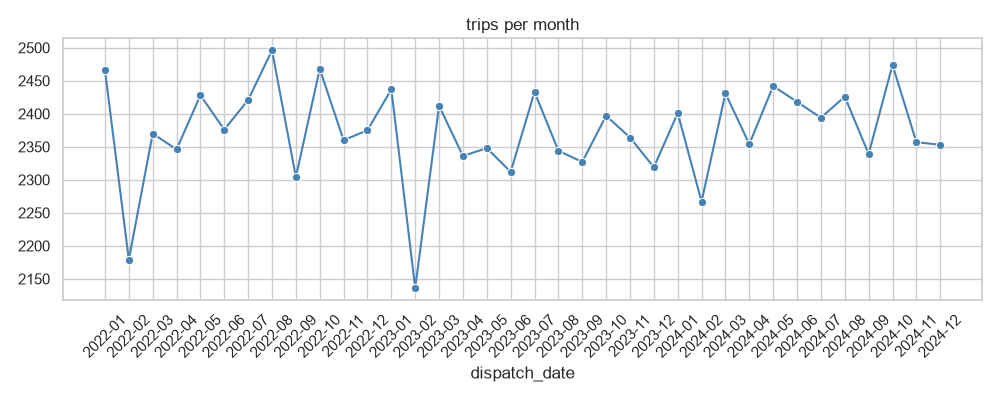

In [7]:
# date spans plus trips per month
for name, col in [
    ("loads", "load_date"),
    ("trips", "dispatch_date"),
    ("fuel_purchases", "purchase_date"),
    ("drivers", "hire_date"),
    ("customers", "contract_start_date"),
]:
    s = frames[name][col]
    print(
        name,
        col,
        s.min(),
        "->",
        s.max(),
        "null_pct=",
        round(float(s.isna().mean()) * 100, 2),
    )
months = (
    pd.to_datetime(trips["dispatch_date"], errors="coerce", format="mixed")
    .dt.to_period("M")
    .astype(str)
    .value_counts()
    .sort_index()
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(x=months.index, y=months.values, marker="o", ax=ax, color="steelblue")
ax.set_title("trips per month")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(PLOTS / "monthly_trips.png", dpi=100)
plt.close(fig)
display(Image(str(PLOTS / "monthly_trips.png")))

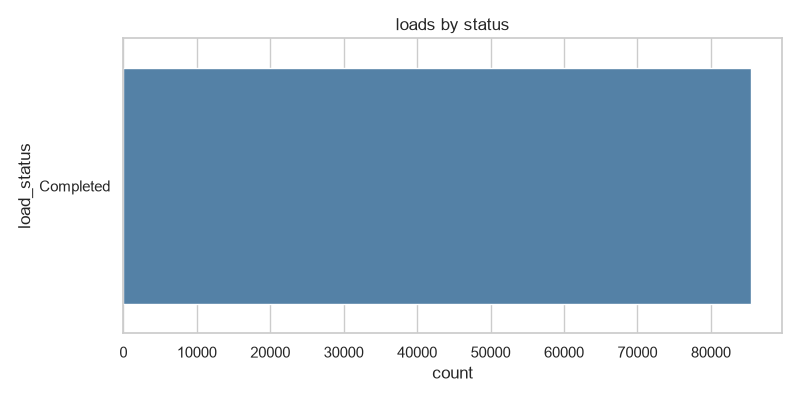

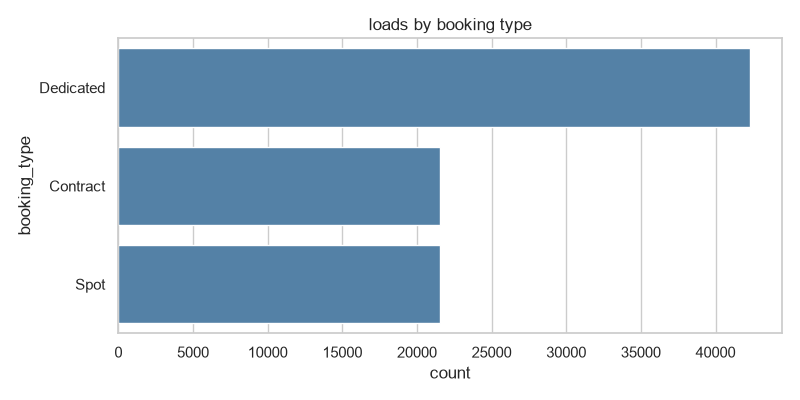

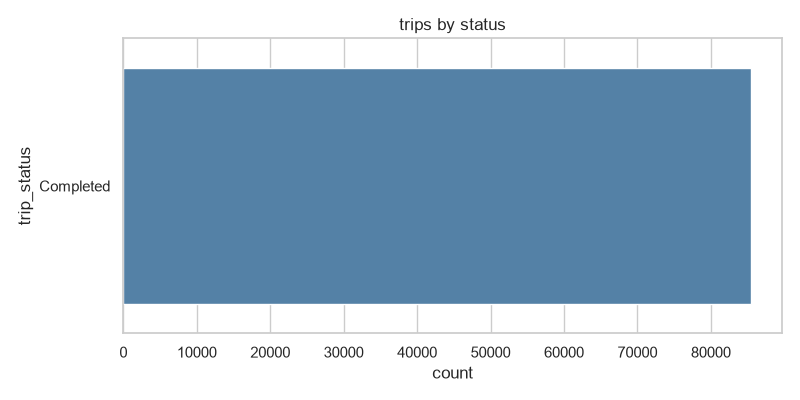

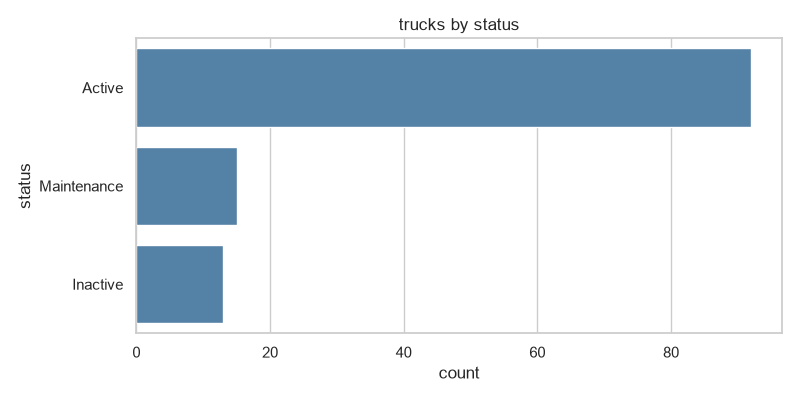

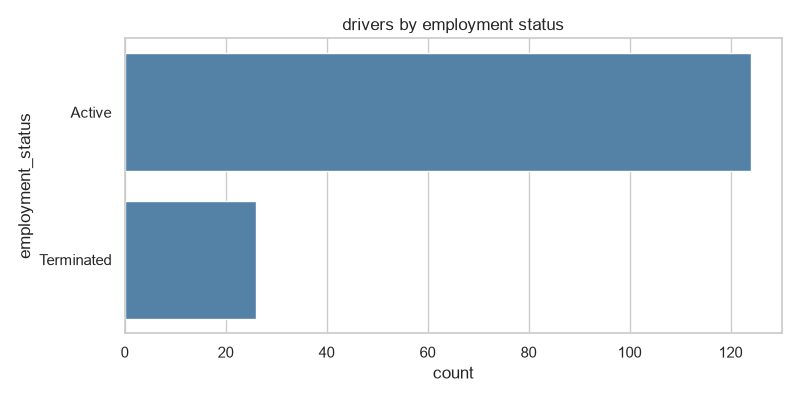

In [8]:
# status splits across loads, trips, trucks, drivers
def countplot(frame, column, title, fname):
    order = frame[column].value_counts().head(12).index
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.countplot(data=frame, y=column, order=order, ax=ax, color="steelblue")
    ax.set_title(title)
    fig.tight_layout()
    path = PLOTS / fname
    fig.savefig(path, dpi=100)
    plt.close(fig)
    display(Image(str(path)))


countplot(loads, "load_status", "loads by status", "counts_load_status.png")
countplot(loads, "booking_type", "loads by booking type", "counts_booking_type.png")
countplot(trips, "trip_status", "trips by status", "counts_trip_status.png")
countplot(frames["trucks"], "status", "trucks by status", "counts_truck_status.png")
countplot(
    frames["drivers"],
    "employment_status",
    "drivers by employment status",
    "counts_driver_status.png",
)

In [9]:
# orphan foreign keys against parent id sets
FKS = {
    "loads.customer_id": ("customers", "customer_id"),
    "loads.route_id": ("routes", "route_id"),
    "trips.load_id": ("loads", "load_id"),
    "trips.driver_id": ("drivers", "driver_id"),
    "trips.truck_id": ("trucks", "truck_id"),
    "trips.trailer_id": ("trailers", "trailer_id"),
    "fuel_purchases.trip_id": ("trips", "trip_id"),
    "fuel_purchases.truck_id": ("trucks", "truck_id"),
    "fuel_purchases.driver_id": ("drivers", "driver_id"),
}
fks = {}
for child_col, (parent_table, parent_col) in FKS.items():
    child, column = child_col.split(".")
    orphans = set(frames[child][column].dropna().astype(str)) - set(
        frames[parent_table][parent_col].dropna().astype(str)
    )
    fks[child_col] = {
        "orphans": len(orphans),
        "orphan_pct": round(
            len(orphans)
            / max(len(set(frames[child][column].dropna().astype(str))), 1)
            * 100,
            2,
        ),
    }
    print(
        child_col,
        "orphans=",
        fks[child_col]["orphans"],
        f"({fks[child_col]['orphan_pct']}%)",
    )
stats["fks"] = fks

loads.customer_id orphans= 0 (0.0%)
loads.route_id orphans= 0 (0.0%)


trips.load_id orphans= 0 (0.0%)
trips.driver_id orphans= 0 (0.0%)


trips.truck_id orphans= 0 (0.0%)
trips.trailer_id orphans= 0 (0.0%)


fuel_purchases.trip_id orphans= 0 (0.0%)


fuel_purchases.truck_id orphans= 0 (0.0%)


fuel_purchases.driver_id orphans= 0 (0.0%)


In [10]:
# loaded_at verdict plus stats snapshot for the report
for name, frame in frames.items():
    col = frame.get("loaded_at")
    stats[name]["loaded_at"] = {
        "null_pct": round(float(col.isna().mean()) * 100, 2),
        "uniques": int(col.nunique()),
    }
    print(name, stats[name]["loaded_at"])
(ROOT / "notebooks" / "stats_databricks.json").write_text(
    json.dumps(stats, indent=1, default=str)
)
print("saved stats_databricks.json")

customers {'null_pct': 0.0, 'uniques': 1}
drivers {'null_pct': 0.0, 'uniques': 1}
facilities {'null_pct': 0.0, 'uniques': 1}
fuel_purchases {'null_pct': 0.0, 'uniques': 1}
loads {'null_pct': 0.0, 'uniques': 1}
routes {'null_pct': 0.0, 'uniques': 1}
trailers {'null_pct': 0.0, 'uniques': 1}
trips {'null_pct': 0.0, 'uniques': 1}
trucks {'null_pct': 0.0, 'uniques': 1}
saved stats_databricks.json
